In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

In [2]:
X = np.array([[0.4, -0.7],
              [-1.5, -1.0],
              [-1.4, -0.9],
              [-1.3, -1.2],
              [-1.1, -0.2],
              [-1.2, -0.4],
              [-0.5, 1.2],
              [-1.5, 2.1],
              [1.0, 1.0],
              [1.3, 0.8],
              [1.2, 0.5],
              [0.2, -2.0],
              [0.5, -2.4],
              [0.2, -2.3],
              [0.0, -2.7],
              [1.3, 2.1]])
Y = np.array([-1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1])

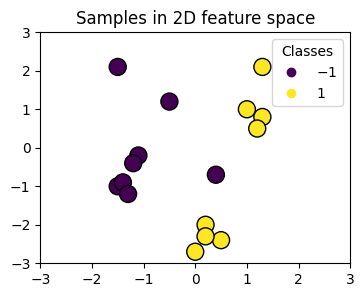

In [3]:
#visualize data in 2D space
fig, ax = plt.subplots(figsize=(4, 3))
X_min, X_max, Y_min, Y_max = -3, 3, -3, 3
ax.set(xlim=(X_min, X_max), ylim=(Y_min, Y_max))
scatter = ax.scatter(X[:, 0], X[:, 1], s=150, c=Y, label=Y, edgecolors='k')
ax.legend(*scatter.legend_elements(), loc='upper right', title='Classes')
ax.set_title('Samples in 2D feature space')
plt.show()

In [4]:
#boundary plotting function
def plot_data_with_decision_boundary(kr):
    #train SVM model with specific kernel configurations
    clf = svm.SVC(kernel=kr, gamma=0.001, C=1, degree=2)
    clf.fit(X, Y)
    
    #configure plotting boundaries 
    fig, ax = plt.subplots(figsize=(4, 3))
    X_min, X_max, Y_min, Y_max = -3, 3, -3, 3
    ax.set(xlim=(X_min, X_max), ylim=(Y_min, Y_max))
    common_params = {'estimator': clf, 'X': X, 'ax': ax}
    
    #render decision regions background mapping
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method='predict',
        plot_method='pcolormesh',
        alpha=0.3
    )
    
    #render decision margin and hyperplane contour lines
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method='decision_function',
        plot_method='contour',
        levels=[-1, 0, 1],
        colors=['pink', 'black', 'red']
       #  linesStyle=['--', '-', '--'] # LINE giving warning
    )
    
    #overlay support vectors and original data points
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=250, facecolors='none', edgecolors='k')
    ax.scatter(X[:, 0], X[:, 1], c=Y, s=150, edgecolors='k')
    ax.legend(*scatter.legend_elements(), loc='upper right', title='Classes')
    ax.set_title(f'Decision boundries of {kr} kernel in SVC')
    plt.show()

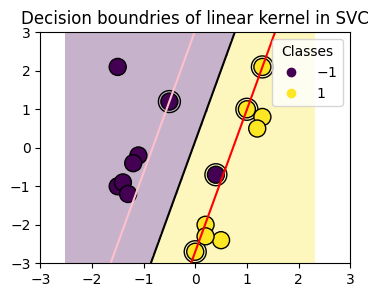

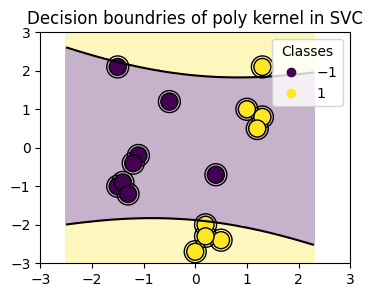

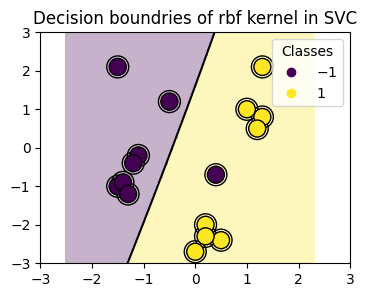

In [7]:
plot_data_with_decision_boundary('linear')
plot_data_with_decision_boundary('poly')
plot_data_with_decision_boundary('rbf')